# 3 — Simulate, reconstruct, quantify

Both `.seq` files from notebook 2, played against a numerical phantom and taken all the way to an ADC
map. The steps are the ones a real scan needs, in the order a real scan needs them:

1. reconstruct the **field map** from its own two echoes,
2. reconstruct the **DTI** using that field map,
3. fit the diffusivity.

Nothing here knows it is a simulation. `data` is `(n_coils, n_samples)`; on the scanner the same call
takes the same array out of a twix reader. The last section says exactly what changes.

In [1]:
%matplotlib inline
import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

sys.path.insert(0, str(Path('lib').resolve()))

import seqcraft as sc
from mr0_bridge import phantom_with_diffusion, simulate, to_mr0
from spiral_recon import Readout, reconstruct_volume

warnings.filterwarnings('ignore')
print('seqcraft', sc.__version__)

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


seqcraft 0.3.0


## 1. The two sequences, and a phantom to play them against

The phantom grid is finer than either reconstruction, so the simulation is not band-limited to the
thing being measured. Three discs of different diffusivity, placed asymmetrically; a B0 map that is a
smooth gradient plus a local blob, which is what a shim residual looks like.

In [2]:
SEQ_DIR = Path('seq')
REGIME = 'dwi'
system = sc.System.preset('cima_x').derate(REGIME, grad=0.85, slew=0.50)

dti_seq = pp.Sequence(system=system.limits(REGIME))
dti_seq.read(str(next(SEQ_DIR.glob('spiral_dti_*.seq'))))
readout = Readout.from_sidecar(next(SEQ_DIR.glob('spiral_dti_*.traj.npz')))
with np.load(next(SEQ_DIR.glob('spiral_dti_*.traj.npz'))) as extra:
    B_USED = float(extra['achieved_b_values'][-1])
    DIRECTION = tuple(float(v) for v in extra['directions'][0])
    TE = float(extra['te_s'])

b0_seq = pp.Sequence(system=system.limits(REGIME))
b0_seq.read(str(next(SEQ_DIR.glob('b0map_*.seq'))))
with np.load(next(SEQ_DIR.glob('b0map_*.meta.npz'))) as meta_npz:
    B0_TE_S = tuple(float(v) for v in meta_npz['te_s'])
    B0_DTE = float(meta_npz['delta_te_s'])
    B0_MATRIX = int(meta_npz['matrix'])
    B0_LINES = np.asarray(meta_npz['lines'], dtype=int)
    B0_DUMMIES = int(meta_npz['dummies'])
    B0_POLARITY = tuple(int(v) for v in meta_npz['polarity'])

MATRIX = readout.matrix
N_INTERLEAVES = readout.n_interleaves
FOV_M = readout.fov_m
SLICE_MM = 4.0
# MRzero materialises a samples x voxels array, so this is bounded by memory rather than by
# patience: 160 against a 67 000-sample readout asks for 7.6 GB and fails outright.
PHANTOM_N = 128
N_COILS = 8
D_TRUE = 1.5           # 1e-3 mm^2/s

print(f'DTI       {MATRIX}x{MATRIX}, {N_INTERLEAVES} shots x {readout.n_samples} samples, '
      f'{readout.t_adc_s.max() * 1e3:.1f} ms readout, TE {TE * 1e3:.2f} ms, b {B_USED:.0f}')
print(f'field map {B0_MATRIX}x{B0_MATRIX}, TE {B0_TE_S[0] * 1e3:.2f} / {B0_TE_S[1] * 1e3:.2f} ms, '
      f'unambiguous +-{1 / (2 * B0_DTE):.0f} Hz')

DTI       128x128, 4 shots x 6840 samples, 17.1 ms readout, TE 29.08 ms, b 1000
field map 128x128, TE 4.00 / 6.38 ms, unambiguous +-210 Hz


In [3]:
axis = (np.arange(PHANTOM_N) - PHANTOM_N / 2) / PHANTOM_N
grid_y, grid_x = np.meshgrid(axis, axis, indexing='ij')      # every map here is [y, x]
b0_truth = (60.0 * grid_x
            + 50.0 * np.exp(-((grid_x - 0.18) ** 2 + (grid_y + 0.10) ** 2) / (2 * 0.07 ** 2))
            ).astype(np.float32)

phantom, maps = phantom_with_diffusion(
    size_m=(FOV_M, FOV_M, SLICE_MM / 1e3), matrix=PHANTOM_N, d_1e_3_mm2_s=D_TRUE,
    b0_hz=b0_truth, shape='blobs', n_coils=N_COILS)


def on_grid(field, matrix):
    '''Resample a map onto a square grid of any size, by linear interpolation.

    Nearest neighbour looks equivalent and is not: at a non-integer grid ratio it duplicates and
    skips rows, and a B0 map with that pattern in it puts a periodic phase error into the correction.
    '''
    array = np.asarray(field)
    if np.iscomplexobj(array):
        return (on_grid(array.real, matrix) + 1j * on_grid(array.imag, matrix)).astype(np.complex64)
    source = (np.arange(array.shape[-1]) - array.shape[-1] / 2) / array.shape[-1]
    target = (np.arange(matrix) - matrix / 2) / matrix
    rows = np.apply_along_axis(lambda line: np.interp(target, source, line), -1,
                              array.astype(np.float64))
    return np.apply_along_axis(lambda line: np.interp(target, source, line), -2, rows)


print(f'{int((maps["PD"] > 0).sum())} voxels on {PHANTOM_N}x{PHANTOM_N}, {N_COILS} channels')
print(f'D present {sorted(set(np.round(maps["D"][maps["PD"] > 0], 3)))} e-3 mm2/s')
print(f'B0 {b0_truth.min():.0f} .. {b0_truth.max():.0f} Hz  ->  '
      f'{np.abs(b0_truth).max() * readout.t_adc_s.max():.1f} cycles over the spiral readout')

9085 voxels on 128x128, 8 channels
D present [np.float32(0.375), np.float32(1.5), np.float32(3.75)] e-3 mm2/s
B0 -30 .. 61 Hz  ->  1.0 cycles over the spiral readout


## 2. The field map

Two echoes, Cartesian, so a plain inverse FFT per echo. Off-resonance is the phase difference over
`2π·ΔTE`; the echo spacing keeps that inside ±½ΔTE⁻¹ so nothing needs unwrapping.

In [4]:
b0_mr0, b0_meta = to_mr0(b0_seq, system=system, event_dt_s=500e-6)
b0_signal = simulate(b0_mr0, phantom)
print(f'{b0_meta.n_reps} shots, {b0_meta.n_samples} samples')

# One shot per phase-encode line, each carrying both echoes -- so each acquiring repetition holds
# 2 x n_samples, the first echo then the second.  The dummies carry no ADC and so no repetition here.
acquiring = [rep for rep in range(b0_meta.n_reps) if b0_meta.samples_of_rep(rep).size]
per_echo = b0_meta.samples_of_rep(acquiring[0]).size // len(B0_TE_S)
print(f'{len(acquiring)} acquiring repetitions of {b0_meta.n_reps}, '
      f'{per_echo} samples per echo')

echoes = []
for echo, polarity in enumerate(B0_POLARITY):
    kspace = np.zeros((B0_MATRIX, B0_MATRIX), dtype=complex)
    for row, line in enumerate(B0_LINES):
        samples = b0_meta.samples_of_rep(acquiring[row])[echo * per_echo:(echo + 1) * per_echo]
        # `polarity` is +1 for both echoes: the sequence flies back between them rather than
        # reversing the gradient, so both are read on the same k grid and need no flipping.  It is
        # kept in the sidecar because a reversed echo would need `[::polarity]` here, and getting
        # that wrong puts a linear ramp of 1/dTE across the field map -- the full unambiguous range.
        kspace[line] = b0_signal[samples, 0][::polarity]
    # S(kx, ky) = sum m[y, x] exp(-2i pi (kx x + ky y)), so the image is a plain inverse transform.
    echoes.append(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace))))

# The signal accumulates exp(-2i pi df t), so the *later* echo lags: angle(echo0 . conj(echo1))
# is +2 pi df dTE.  Taking the pair the other way round returns -df, which looks entirely plausible
# -- a field map with the right shape and range -- and makes the correction add the blur it should
# remove.  The check against the truth below is what catches it; on the scanner, reconstruct once
# with the map and once with its negative and keep the sharper one.
field_measured = np.angle(echoes[0] * np.conj(echoes[1])) / (2 * np.pi * B0_DTE)
support = np.abs(echoes[0]) > 0.1 * np.abs(echoes[0]).max()
field_measured = np.where(support, field_measured, 0.0).astype(np.float32)

truth_on_b0 = on_grid(b0_truth, B0_MATRIX)
error = field_measured[support] - truth_on_b0[support]
print(f'measured field {field_measured[support].min():+.0f} .. '
      f'{field_measured[support].max():+.0f} Hz')
print(f'  versus the truth: mean error {error.mean():+.2f} Hz, '
      f'RMS {np.sqrt((error ** 2).mean()):.2f} Hz over {int(support.sum())} pixels')

188 shots, 32768 samples
128 acquiring repetitions of 188, 128 samples per echo
measured field -26 .. +61 Hz
  versus the truth: mean error -0.01 Hz, RMS 0.84 Hz over 9093 pixels


## 3. The DTI

Two shots: the unweighted volume, and the first weighted one. The sequence acquires `b=0` first and
`+x` second, which is what a one-voxel-thick phantom can represent — the slice-axis gradients are
dropped, so a `z` direction would go with them.

The field map goes in as it comes out of section 2, resampled onto the reconstruction grid. Nothing is
transposed and no sign is flipped: the operator's conventions are trajectory in as `(kx, ky)`, image
out as `[y, x]`, off-resonance as `exp(-2πi(k·r + Δf·t))`.

**The fat saturation is skipped here, and it has to be.** MRzero's pulses are instantaneous ideal
rotations, so they cannot be frequency selective — a −419 Hz fat-sat pulse simulates as an
on-resonance 90°, which saturates *water*. Simulated that way the signal falls by two orders of
magnitude, and because its spoiler lies on the slice axis, which a one-voxel-thick phantom forces us
to drop, the leftover transverse magnetisation survives into the readout and interferes with the echo.
That interference has a phase of `2π·Δf·Δt`, so it cancels the wanted signal wherever the field takes
the wrong value — a dark band through the image that no field map can correct, because it is
contamination in the data rather than blur. On the scanner the pulse is frequency selective and its
spoiler works, so the fix is to start the simulation at the excitation rather than to change the
sequence.

In [5]:
SHOT_REPS = 3          # fat sat + excitation + refocusing, per shot in the file
SKIP_FAT_SAT = 1       # ... but the fat sat is not simulated -- see below
field = on_grid(field_measured, MATRIX).astype(np.float32)
sens = on_grid(maps['coil_sens'], MATRIX)


def acquire(shot):
    '''Simulate one shot of the played file: (n_coils, n_samples).

    One shot at a time because MRzero materialises a samples x voxels array, and a whole volume's
    worth at once would ask for several gigabytes.  A 6 s TR and a spoiler make the shots
    independent, so taking them one at a time is exact rather than an approximation.
    '''
    mr0_seq, meta = to_mr0(dti_seq, system=system, event_dt_s=200e-6,
                           first_rep=shot * SHOT_REPS + SKIP_FAT_SAT,
                           max_reps=SHOT_REPS - SKIP_FAT_SAT)
    signal = simulate(mr0_seq, phantom)
    chosen = meta.samples_of_rep(int(np.unique(meta.adc_rep)[0]))
    return signal[chosen, :].T


# The file acquires every interleaf of a volume before moving on, so volume v interleaf i is shot
# v * N_INTERLEAVES + i.  On real data the two indices are the SET and SEG labels.
volumes = {}
for volume, name in enumerate(('b0', 'weighted')):
    volumes[name] = [acquire(volume * N_INTERLEAVES + i) for i in range(N_INTERLEAVES)]

# All interleaves solved together, not reconstructed separately and averaged: alone each covers a
# quarter of k-space and is severely aliased, and averaging four aliased images keeps the aliasing.
images = {name: reconstruct_volume(shots, readout, b0_hz=field, sens=sens, iterations=20)
          for name, shots in volumes.items()}
uncorrected = {name: reconstruct_volume(shots, readout, b0_hz=0.0, sens=sens, iterations=20)
               for name, shots in volumes.items()}
print(f'reconstructed {MATRIX}x{MATRIX} from {N_INTERLEAVES} x {readout.n_samples} samples '
      f'x {N_COILS} channels')

reconstructed 128x128 from 4 x 6840 samples x 8 channels


## 4. Quantify

In [6]:
magnitude_b0 = np.abs(images['b0'])
magnitude_weighted = np.abs(images['weighted'])
mask = magnitude_b0 > 0.15 * magnitude_b0.max()


def adc_from(unweighted, weighted):
    '''An apparent-diffusion map from one b = 0 and one weighted image.'''
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(mask, np.abs(weighted) / np.abs(unweighted), np.nan)
        return -np.log(ratio) / (B_USED * 1e-3)


adc_map = adc_from(images['b0'], images['weighted'])
adc_uncorrected = adc_from(uncorrected['b0'], uncorrected['weighted'])

truth_d = on_grid(maps['D'], MATRIX)
print(f'diffusion direction {DIRECTION}, b = {B_USED:.0f} s/mm2')
print()
print(f'{"region":>14} {"true D":>8} {"measured":>9} {"uncorrected":>12} {"pixels":>8}')
for name, scale in (('background', 1.0), ('restricted', 0.25), ('free water', 2.5)):
    wanted = D_TRUE * scale
    region = np.abs(truth_d - wanted) < 1e-3
    interior = region.copy()       # drop boundary pixels, where two diffusivities are averaged
    for shift in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        interior &= np.roll(region, shift, axis=(0, 1))
    keep = interior & mask & np.isfinite(adc_map)
    measured = float(np.nanmean(adc_map[keep])) if keep.any() else float('nan')
    raw = float(np.nanmean(adc_uncorrected[keep])) if keep.any() else float('nan')
    print(f'{name:>14} {wanted:8.2f} {measured:9.2f} {raw:12.2f} {int(keep.sum()):8d}')

diffusion direction (1.0, 0.0, 0.0), b = 1000 s/mm2

        region   true D  measured  uncorrected   pixels
    background     1.50      1.50         1.50     7466
    restricted     0.38      0.36         0.36      654
    free water     3.75      4.10         3.93      355


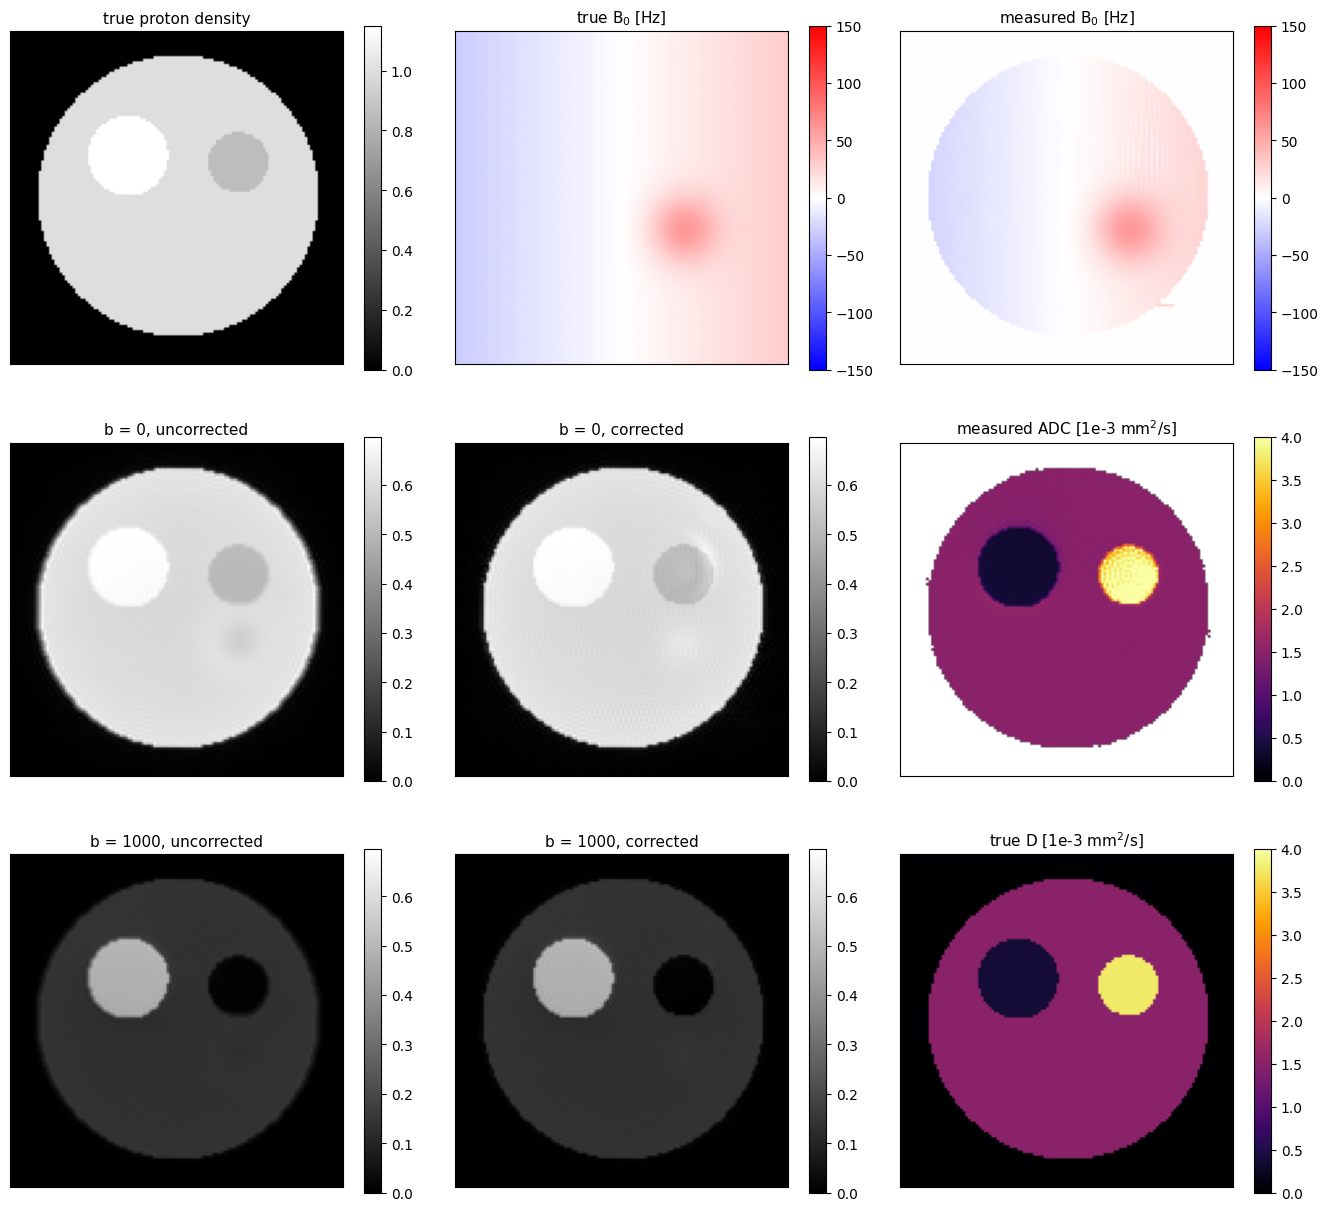

In [7]:
figure, axes = plt.subplots(3, 3, figsize=(13.5, 12.6))
bright = float(np.percentile(magnitude_b0, 99.5))
truth_pd = maps['PD']
panels = [
    ('true proton density', truth_pd, 'gray', (0, float(truth_pd.max()))),
    ('true B$_0$ [Hz]', b0_truth, 'bwr', (-150, 150)),
    ('measured B$_0$ [Hz]', field_measured, 'bwr', (-150, 150)),

    ('b = 0, uncorrected', np.abs(uncorrected['b0']), 'gray', (0, bright)),
    ('b = 0, corrected', magnitude_b0, 'gray', (0, bright)),
    ('measured ADC [1e-3 mm$^2$/s]', adc_map, 'inferno', (0, 4)),

    (f'b = {B_USED:.0f}, uncorrected', np.abs(uncorrected['weighted']), 'gray', (0, bright)),
    (f'b = {B_USED:.0f}, corrected', magnitude_weighted, 'gray', (0, bright)),
    ('true D [1e-3 mm$^2$/s]', truth_d, 'inferno', (0, 4)),
]
for handle, (title, data, cmap, limits) in zip(axes.ravel(), panels):
    image = handle.imshow(data, cmap=cmap, origin='lower', vmin=limits[0], vmax=limits[1])
    handle.set_title(title, fontsize=11)
    handle.set_xticks([]); handle.set_yticks([])
    plt.colorbar(image, ax=handle, shrink=0.85)
figure.tight_layout()
plt.show()

## 5. On the scanner

The reconstruction never learns where its data came from, so only the source changes:

```python
import twixtools
scan  = twixtools.read_twix('meas_MID123_spiral_dti.dat')[-1]
lines = [mdb for mdb in scan['mdb'] if mdb.is_image_scan()]
data  = np.stack([mdb.data for mdb in lines])      # (n_acquisitions, n_coils, n_samples)

image = reconstruct_shot(data[shot], readout, b0_hz=field_map, sens=espirit_maps)
```

`SET` labels the volume in the DTI file; `LIN` and `ECO` label the line and echo in the field map.

Four things to check, none of which the code can check for you:

| | why it bites |
|---|---|
| **sample count** | vendors prepend dummy or oversampled points. A mismatch against `readout.n_samples` raises rather than producing noise. |
| **channel order** | must match the coil maps, and a reader may reorder or compress channels |
| **gradient delay** | a microsecond or two shifts the trajectory against the data. On a spiral that is a ring or a shading, and no field map explains it — measure it, then shift `t_adc_s`. |
| **field-map sign** | the operator uses `exp(-2πi(k·r + Δf·t))`. If a vendor field map is defined the other way, reconstruct once with the map and once with its negative and keep the better one. |

Two things this simulation cannot tell you: the phantom is one voxel thick, so nothing here tests
through-slice behaviour; and there is no eddy-current, concomitant-field or gradient-delay modelling,
which is why the table above is where to look first if the scanner image has an artefact this does not.